# HAR regression with elastic net

Companion to `HAR_RegressionWithRegularisation.ipynb` (ridge, runs 15–17). That notebook
found the L2 **shrinkage** added essentially nothing — the QLIKE gain over OLS came purely
from **exponentially weighting** recent observations (best λ≈0.995). Here we test whether
**elastic net** does better. Elastic net adds an **L1** term to ridge's L2 (mix set by
`l1_ratio`: 0→ridge, 1→lasso), so it can *zero out* collinear regressors (e.g. the weekly /
monthly HAR term or the cross-asset RV) rather than merely shrink them. Both the penalty
`alpha` and `l1_ratio` are chosen by **whole-window k-fold cross-validation** (`ElasticNetCV`,
no look-ahead) on the same EWMA-weighted data, with the same Duan-smearing back-transform and
QLIKE-in-levels scoring as the ridge notebook.

Elastic-net runs (analogues of the OLS log+GVZ runs in the source notebook):
- **Run 18** — elastic net of Run 4:  log HAR + log GVZ
- **Run 19** — elastic net of Run 10: log HAR + log SPX + log GVZ
- **Run 20** — elastic net of Run 14: log HAR + log crude + log GVZ

In [1]:
# ===========================================================================
# Cell 1 — Imports & data
# ===========================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet, ElasticNetCV
from sklearn.preprocessing import StandardScaler

# Same aligned daily realized-variance panel used by SimpleHAR_Regressions.ipynb
data = pd.read_parquet("merged_RV_GVZ.parquet")
rv = data["RV_gold"].astype(float)

WINDOW = 500      # rolling estimation window (matches the OLS / ridge runs)
EPS = 1e-6        # QLIKE forecast floor

print(f"RV_gold: {len(rv)} obs, {rv.index.min().date()} .. {rv.index.max().date()}")
print(f"Columns available: {list(data.columns)}")

RV_gold: 4114 obs, 2010-01-04 .. 2026-05-29
Columns available: ['RV_gold', 'RV_crude', 'RV_ES', 'GVZ_close']


In [2]:
# ===========================================================================
# Cell 2 — Build the 3 log+GVZ design tables (mirror SimpleHAR Cells 7 & 11)
# ===========================================================================
# Log-HAR components on x = log(RV_gold):
#   x_d[t]=x_t, x_w[t]=mean(x_{t-4..t}), x_m[t]=mean(x_{t-21..t})
#   y_log[t]=x_{t+1}=log(RV_{t+1}); y_level[t]=RV_{t+1} (kept for QLIKE in levels).
# Exogenous day-t terms are logged and known at the close (no look-ahead).

# Strict positivity required for every logged input
for col in ["RV_gold", "GVZ_close", "RV_ES", "RV_crude"]:
    assert (data[col] > 0).all(), f"{col} has non-positive values; log undefined"

x = np.log(rv)

def build_log_design(extra_cols):
    """Base log-HAR design + optional logged exogenous day-t columns (dict name->series)."""
    df = pd.DataFrame(index=rv.index)
    df["x_d"] = x
    df["x_w"] = x.rolling(5).mean()
    df["x_m"] = x.rolling(22).mean()
    for name, series in extra_cols.items():
        df[name] = series.reindex(rv.index)
    df["y_log"]   = x.shift(-1)        # log(RV_{t+1})
    df["y_level"] = rv.shift(-1)       # RV_{t+1} in levels, for QLIKE
    return df.dropna()

log_gvz   = np.log(data["GVZ_close"])
log_spx   = np.log(data["RV_ES"])
log_crude = np.log(data["RV_crude"])

# Run 18 / 19 / 20 design tables
d_gvz       = build_log_design({"log_GVZ": log_gvz})
d_spx_gvz   = build_log_design({"log_GVZ": log_gvz, "log_RV_ES": log_spx})
d_crude_gvz = build_log_design({"log_GVZ": log_gvz, "log_RV_crude": log_crude})

for name, df in [("d_gvz", d_gvz), ("d_spx_gvz", d_spx_gvz), ("d_crude_gvz", d_crude_gvz)]:
    assert df.notna().all().all(), f"unexpected NaNs in {name}"

print("Run 18  log+GVZ        cols:", list(d_gvz.columns),       f"({len(d_gvz)} rows)")
print("Run 19  log+SPX+GVZ    cols:", list(d_spx_gvz.columns),   f"({len(d_spx_gvz)} rows)")
print("Run 20  log+crude+GVZ  cols:", list(d_crude_gvz.columns), f"({len(d_crude_gvz)} rows)")
d_gvz.head()

Run 18  log+GVZ        cols: ['x_d', 'x_w', 'x_m', 'log_GVZ', 'y_log', 'y_level'] (4092 rows)
Run 19  log+SPX+GVZ    cols: ['x_d', 'x_w', 'x_m', 'log_GVZ', 'log_RV_ES', 'y_log', 'y_level'] (4092 rows)
Run 20  log+crude+GVZ  cols: ['x_d', 'x_w', 'x_m', 'log_GVZ', 'log_RV_crude', 'y_log', 'y_level'] (4092 rows)


,x_d,x_w,x_m,log_GVZ,y_log,y_level
Date,,,,,,
2010-02-03,2.850663,2.981362,2.933665,3.095125,3.580491,35.891145
2010-02-04,3.580491,3.080406,2.967351,3.302849,3.444815,31.337489
2010-02-05,3.444815,3.158204,2.994161,3.317453,2.911737,18.388714
2010-02-08,2.911737,3.146146,2.996290,3.291383,2.940123,18.918172
2010-02-09,2.940123,3.145566,3.005753,3.236716,3.123939,22.735769


In [3]:
# ===========================================================================
# Cell 3 — Shared helpers: QLIKE, OLS baseline, EWMA-weighted elastic net
# ===========================================================================
# QLIKE (Patton 2011 robust form), floored so log is defined.
def _qlike(actual, forecast, eps=EPS):
    f = np.maximum(forecast, eps)
    r = actual / f
    return r - np.log(r) - 1.0, int((forecast <= eps).sum())

# --- OLS baseline (identical protocol to SimpleHAR Cell 13) ---
# 500-day rolling log-space OLS + Duan smearing back-transform -> avg QLIKE.
def rolling_log_qlike_smearing(design, feat_cols, ylog_col, ylevel_col, window=WINDOW):
    X = np.column_stack([np.ones(len(design)), design[feat_cols].to_numpy()])
    yl  = design[ylog_col].to_numpy()
    lvl = design[ylevel_col].to_numpy()
    fc, ac = [], []
    for t in range(window, len(design)):
        Xw, yw = X[t - window:t], yl[t - window:t]
        beta, *_ = np.linalg.lstsq(Xw, yw, rcond=None)
        smearing = np.mean(np.exp(yw - Xw @ beta))          # Duan factor
        fc.append(np.exp(X[t] @ beta) * smearing); ac.append(lvl[t])
    q, clip = _qlike(np.array(ac), np.array(fc))
    return q.mean(), len(q), clip

# --- Elastic net: same rolling protocol, EWMA-weighted, alpha & l1_ratio by CV ---
# Observation t-k in the window is weighted by lam**k (lam, EWMA decay) so recent data
# dominates; ElasticNetCV's whole-window k-fold CV (on the weighted data, no look-ahead)
# jointly picks the penalty alpha and the L1/L2 mix l1_ratio (0->ridge, 1->lasso).
# Standardisation matters because the penalty is scale-dependent.
LAMBDA = 0.94                              # EWMA decay (RiskMetrics daily standard)
L1_RATIOS = [0.1, 0.5, 0.7, 0.9, 1.0]      # L1/L2 mixes searched by CV
N_ALPHAS, CV = 30, 3                       # per-l1_ratio alpha path length, CV folds

def rolling_log_elasticnet_qlike(design, feat_cols, ylog_col, ylevel_col,
                                 l1_ratios=L1_RATIOS, window=WINDOW, lam=LAMBDA):
    Xf  = design[feat_cols].to_numpy()
    yl  = design[ylog_col].to_numpy()
    lvl = design[ylevel_col].to_numpy()
    w = lam ** np.arange(window)[::-1]      # oldest..newest -> lam**(age)
    w = w / w.mean()                         # mean weight 1 (comparable to unweighted)
    fc, ac, a_sel, l1_sel = [], [], [], []
    for t in range(window, len(design)):
        Xw, yw = Xf[t - window:t], yl[t - window:t]
        sc = StandardScaler().fit(Xw)
        Xw_s = sc.transform(Xw)
        m = ElasticNetCV(l1_ratio=l1_ratios, n_alphas=N_ALPHAS, cv=CV,
                         fit_intercept=True, max_iter=5000).fit(Xw_s, yw, sample_weight=w)
        x_hat = m.predict(sc.transform(Xf[t:t + 1]))[0]
        smearing = np.average(np.exp(yw - m.predict(Xw_s)), weights=w)   # weighted Duan factor
        fc.append(np.exp(x_hat) * smearing); ac.append(lvl[t])
        a_sel.append(m.alpha_); l1_sel.append(m.l1_ratio_)
    q, clip = _qlike(np.array(ac), np.array(fc))
    return q.mean(), len(q), clip, np.array(a_sel), np.array(l1_sel)

eff_n = 1.0 / (1.0 - LAMBDA)
print(f"Helpers ready. ElasticNetCV: l1_ratios={L1_RATIOS}, n_alphas={N_ALPHAS}, cv={CV}; "
      f"EWMA weights lambda={LAMBDA} (~{eff_n:.0f} effective obs)")

Helpers ready. ElasticNetCV: l1_ratios=[0.1, 0.5, 0.7, 0.9, 1.0], n_alphas=30, cv=3; EWMA weights lambda=0.94 (~17 effective obs)


In [4]:
# ===========================================================================
# Cell 4 — Run OLS baselines + elastic net (runs 18-20)
# ===========================================================================
specs = [
    ("Run 18  log+GVZ",       d_gvz,       ["x_d", "x_w", "x_m", "log_GVZ"]),
    ("Run 19  log+SPX+GVZ",   d_spx_gvz,   ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_ES"]),
    ("Run 20  log+crude+GVZ", d_crude_gvz, ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_crude"]),
]

rows = []
for label, design, feats in specs:
    q_ols, n_ols, _ = rolling_log_qlike_smearing(design, feats, "y_log", "y_level")
    q_en, n_en, clip_en, alphas, l1s = rolling_log_elasticnet_qlike(design, feats, "y_log", "y_level")
    rows.append({"spec": label, "OLS_QLIKE": q_ols, "EN_QLIKE": q_en,
                 "delta": q_en - q_ols, "mean_alpha": alphas.mean(),
                 "median_alpha": np.median(alphas), "mean_l1": l1s.mean(),
                 "n_forecasts": n_en})
    print(f"{label:<24} OLS {q_ols:.6f} | EN {q_en:.6f}  "
          f"(Δ {q_en - q_ols:+.6f})  alpha mean={alphas.mean():.4g}, "
          f"l1_ratio mean={l1s.mean():.3f}")

Run 18  log+GVZ          OLS 0.030577 | EN 0.032590  (Δ +0.002013)  alpha mean=0.05471, l1_ratio mean=0.629


Run 19  log+SPX+GVZ      OLS 0.030723 | EN 0.032987  (Δ +0.002264)  alpha mean=0.0738, l1_ratio mean=0.609


Run 20  log+crude+GVZ    OLS 0.030618 | EN 0.032690  (Δ +0.002072)  alpha mean=0.06466, l1_ratio mean=0.601


In [5]:
# ===========================================================================
# Cell 5 — Consolidated OLS-vs-elastic-net comparison
# ===========================================================================
pd.set_option("display.float_format", lambda v: f"{v:.6f}")
comparison = pd.DataFrame(rows).set_index("spec")
print("Elastic net vs OLS (lower QLIKE = better 1-day-ahead forecast):")
print(comparison.to_string())

improved = comparison.index[comparison["delta"] < 0].tolist()
print(f"\nElastic net improved QLIKE on: {improved if improved else 'none'}")

best_ols = comparison["OLS_QLIKE"].idxmin()
best_en  = comparison["EN_QLIKE"].idxmin()
best_all = comparison[["OLS_QLIKE", "EN_QLIKE"]].min().idxmin()
best_val = comparison[["OLS_QLIKE", "EN_QLIKE"]].min().min()
print(f"Best OLS spec:         {best_ols} ({comparison.loc[best_ols, 'OLS_QLIKE']:.6f})")
print(f"Best elastic-net spec: {best_en} ({comparison.loc[best_en, 'EN_QLIKE']:.6f})")
print(f"Overall best:          {best_all} via {best_val:.6f}")

Elastic net vs OLS (lower QLIKE = better 1-day-ahead forecast):
                       OLS_QLIKE  EN_QLIKE    delta  mean_alpha  median_alpha  mean_l1  n_forecasts
spec                                                                                               
Run 18  log+GVZ         0.030577  0.032590 0.002013    0.054711      0.011906 0.628953         3592
Run 19  log+SPX+GVZ     0.030723  0.032987 0.002264    0.073795      0.014461 0.609104         3592
Run 20  log+crude+GVZ   0.030618  0.032690 0.002072    0.064656      0.015345 0.600529         3592

Elastic net improved QLIKE on: none
Best OLS spec:         Run 18  log+GVZ (0.030577)
Best elastic-net spec: Run 18  log+GVZ (0.032590)
Overall best:          OLS_QLIKE via 0.030577


In [6]:
# ===========================================================================
# Cell 6 — Lambda sweep: slower EWMA decay (>= 50 effective observations)
# ===========================================================================
# Effective obs ~= 1/(1-lambda). Sweep the same decays as the ridge notebook to locate the
# recency sweet spot for elastic net. alpha & l1_ratio are CV-selected per window each time.
LAMBDAS = [0.98, 0.985, 0.99, 0.995, 0.998]   # ~50, 67, 100, 200, 500 effective obs

sweep_rows = []
for lam in LAMBDAS:
    rec = {"lambda": lam, "eff_obs": 1.0 / (1.0 - lam)}
    for label, design, feats in specs:
        q_en, _, _, _, _ = rolling_log_elasticnet_qlike(design, feats, "y_log", "y_level", lam=lam)
        rec[label] = q_en
    sweep_rows.append(rec)
    print(f"lambda={lam} (~{rec['eff_obs']:.0f} obs) done")

sweep = pd.DataFrame(sweep_rows).set_index("lambda")

print("\nOLS baselines (reference):")
for label, *_ in specs:
    print(f"  {label:<22} {comparison.loc[label, 'OLS_QLIKE']:.6f}")

print("\nElastic-net QLIKE by EWMA lambda (lower = better):")
print(sweep.to_string())

print("\nBest lambda per spec vs its OLS baseline:")
for label, *_ in specs:
    best_lam = sweep[label].idxmin()
    best_q   = sweep.loc[best_lam, label]
    ols_q    = comparison.loc[label, "OLS_QLIKE"]
    flag     = "BEATS OLS" if best_q < ols_q else f"still +{best_q - ols_q:.6f} vs OLS"
    print(f"  {label:<22} best lambda={best_lam} (~{1.0/(1.0-best_lam):.0f} obs) "
          f"-> {best_q:.6f}  ({flag})")

lambda=0.98 (~50 obs) done


lambda=0.985 (~67 obs) done


lambda=0.99 (~100 obs) done


lambda=0.995 (~200 obs) done


lambda=0.998 (~500 obs) done

OLS baselines (reference):
  Run 18  log+GVZ        0.030577
  Run 19  log+SPX+GVZ    0.030723
  Run 20  log+crude+GVZ  0.030618

Elastic-net QLIKE by EWMA lambda (lower = better):
            eff_obs  Run 18  log+GVZ  Run 19  log+SPX+GVZ  Run 20  log+crude+GVZ
lambda                                                                          
0.980000  50.000000         0.031012             0.031053               0.030912
0.985000  66.666667         0.030859             0.030874               0.030759
0.990000 100.000000         0.030735             0.030724               0.030704
0.995000 200.000000         0.030547             0.030610               0.030555
0.998000 500.000000         0.030563             0.030655               0.030605

Best lambda per spec vs its OLS baseline:
  Run 18  log+GVZ        best lambda=0.995 (~200 obs) -> 0.030547  (BEATS OLS)
  Run 19  log+SPX+GVZ    best lambda=0.995 (~200 obs) -> 0.030610  (BEATS OLS)
  Run 20  log+crude+G

Run 18  log+GVZ: swept 30 alphas + 8 l1_ratios


Run 19  log+SPX+GVZ: swept 30 alphas + 8 l1_ratios


Run 20  log+crude+GVZ: swept 30 alphas + 8 l1_ratios


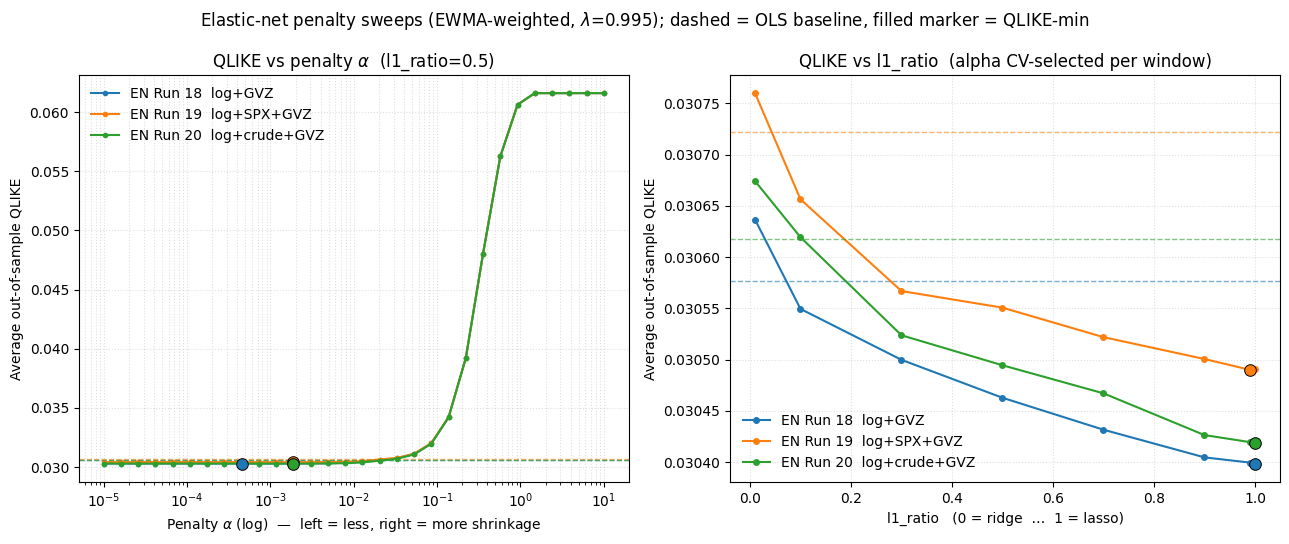


QLIKE-minimising penalty per spec (EWMA lambda=0.995):
  Run 18  log+GVZ        alpha*=0.000452 -> 0.030302 (beats OLS) | l1_ratio*=1.00 -> 0.030399 (beats OLS)
  Run 19  log+SPX+GVZ    alpha*=0.00189 -> 0.030419 (beats OLS) | l1_ratio*=0.99 -> 0.030490 (beats OLS)
  Run 20  log+crude+GVZ  alpha*=0.00189 -> 0.030296 (beats OLS) | l1_ratio*=1.00 -> 0.030418 (beats OLS)


In [7]:
# ===========================================================================
# Cell 7 — QLIKE vs penalty alpha and vs l1_ratio (EWMA lambda=0.995)
# ===========================================================================
# Two views of the elastic-net penalty at the best decay:
#   LEFT  : fix l1_ratio=0.5, sweep the overall penalty alpha (fixed-alpha, no CV).
#   RIGHT : sweep l1_ratio (0->ridge .. 1->lasso); at each, CV-select alpha on the window.
# NB ElasticNet's alpha is 1/(2n)-scaled, so its scale differs from the ridge notebook's.
BEST_LAMBDA = 0.995
ALPHA_GRID  = np.logspace(-5, 1, 30)
L1_GRID     = [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 0.99, 1.0]   # 0.01 ~ near-ridge anchor

def _ewma_w(window, lam):
    w = lam ** np.arange(window)[::-1]
    return w / w.mean()

def rolling_log_elasticnet_fixed(design, feat_cols, ylog_col, ylevel_col,
                                 alpha, l1_ratio, lam=BEST_LAMBDA, window=WINDOW):
    """Rolling EWMA-weighted elastic net with FIXED (alpha, l1_ratio) -> average QLIKE."""
    Xf  = design[feat_cols].to_numpy()
    yl  = design[ylog_col].to_numpy()
    lvl = design[ylevel_col].to_numpy()
    w = _ewma_w(window, lam)
    fc, ac = [], []
    for t in range(window, len(design)):
        Xw, yw = Xf[t - window:t], yl[t - window:t]
        sc = StandardScaler().fit(Xw)
        Xw_s = sc.transform(Xw)
        m = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, fit_intercept=True,
                       max_iter=5000).fit(Xw_s, yw, sample_weight=w)
        x_hat = m.predict(sc.transform(Xf[t:t + 1]))[0]
        smearing = np.average(np.exp(yw - m.predict(Xw_s)), weights=w)
        fc.append(np.exp(x_hat) * smearing); ac.append(lvl[t])
    q, _ = _qlike(np.array(ac), np.array(fc))
    return q.mean()

def rolling_log_elasticnet_cv_at_l1(design, feat_cols, ylog_col, ylevel_col,
                                    l1_ratio, lam=BEST_LAMBDA, window=WINDOW):
    """Rolling EWMA elastic net with fixed l1_ratio, alpha CV-selected per window."""
    Xf  = design[feat_cols].to_numpy()
    yl  = design[ylog_col].to_numpy()
    lvl = design[ylevel_col].to_numpy()
    w = _ewma_w(window, lam)
    fc, ac = [], []
    for t in range(window, len(design)):
        Xw, yw = Xf[t - window:t], yl[t - window:t]
        sc = StandardScaler().fit(Xw)
        Xw_s = sc.transform(Xw)
        m = ElasticNetCV(l1_ratio=[l1_ratio], n_alphas=N_ALPHAS, cv=CV,
                         fit_intercept=True, max_iter=5000).fit(Xw_s, yw, sample_weight=w)
        x_hat = m.predict(sc.transform(Xf[t:t + 1]))[0]
        smearing = np.average(np.exp(yw - m.predict(Xw_s)), weights=w)
        fc.append(np.exp(x_hat) * smearing); ac.append(lvl[t])
    q, _ = _qlike(np.array(ac), np.array(fc))
    return q.mean()

# Sweep both knobs for every spec
alpha_curves, l1_curves = {}, {}
for label, design, feats in specs:
    alpha_curves[label] = np.array([
        rolling_log_elasticnet_fixed(design, feats, "y_log", "y_level", a, 0.5)
        for a in ALPHA_GRID])
    l1_curves[label] = np.array([
        rolling_log_elasticnet_cv_at_l1(design, feats, "y_log", "y_level", v)
        for v in L1_GRID])
    print(f"{label}: swept {len(ALPHA_GRID)} alphas + {len(L1_GRID)} l1_ratios")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.5))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for (label, *_), c in zip(specs, colors):
    ca = alpha_curves[label]
    axL.plot(ALPHA_GRID, ca, marker="o", ms=3, color=c, label=f"EN {label}")
    axL.scatter([ALPHA_GRID[np.argmin(ca)]], [ca.min()], color=c, s=70, zorder=5,
                edgecolor="black", linewidth=0.7)
    axL.axhline(comparison.loc[label, "OLS_QLIKE"], color=c, ls="--", lw=1, alpha=0.6)
    cl = l1_curves[label]
    axR.plot(L1_GRID, cl, marker="o", ms=4, color=c, label=f"EN {label}")
    axR.scatter([L1_GRID[np.argmin(cl)]], [cl.min()], color=c, s=70, zorder=5,
                edgecolor="black", linewidth=0.7)
    axR.axhline(comparison.loc[label, "OLS_QLIKE"], color=c, ls="--", lw=1, alpha=0.6)

axL.set_xscale("log")
axL.set_xlabel(r"Penalty $\alpha$ (log)  —  left = less, right = more shrinkage")
axL.set_ylabel("Average out-of-sample QLIKE")
axL.set_title(r"QLIKE vs penalty $\alpha$  (l1_ratio=0.5)")
axL.legend(frameon=False); axL.grid(True, which="both", ls=":", alpha=0.4)

axR.set_xlabel("l1_ratio   (0 = ridge  …  1 = lasso)")
axR.set_ylabel("Average out-of-sample QLIKE")
axR.set_title("QLIKE vs l1_ratio  (alpha CV-selected per window)")
axR.legend(frameon=False); axR.grid(True, ls=":", alpha=0.4)

fig.suptitle(f"Elastic-net penalty sweeps (EWMA-weighted, $\\lambda$={BEST_LAMBDA}); "
             "dashed = OLS baseline, filled marker = QLIKE-min")
fig.tight_layout()
fig.savefig("qlike_elasticnet_sweeps.png", dpi=150)
plt.show()

print("\nQLIKE-minimising penalty per spec (EWMA lambda=0.995):")
for label, *_ in specs:
    ca, cl = alpha_curves[label], l1_curves[label]
    ols_q = comparison.loc[label, "OLS_QLIKE"]
    fa = "beats OLS" if ca.min() < ols_q else f"+{ca.min() - ols_q:.6f} vs OLS"
    fl = "beats OLS" if cl.min() < ols_q else f"+{cl.min() - ols_q:.6f} vs OLS"
    print(f"  {label:<22} alpha*={ALPHA_GRID[np.argmin(ca)]:.3g} -> {ca.min():.6f} ({fa}) | "
          f"l1_ratio*={L1_GRID[np.argmin(cl)]:.2f} -> {cl.min():.6f} ({fl})")